# Predictive Modeling for Ultimate Technologies

Ultimate is interested in predicting rider retention. A sample dataset of a cohort of users who signed up for an Ultimate account in January 2014 was provided. The data was pulled several months later; we consider a user retained if they were “active” (i.e. took a trip) in the preceding 30 days.

## Data Wrangling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
import seaborn as sns
from datetime import datetime, timedelta


In [2]:
df = pd.read_json('ultimate_data_challenge.json')

In [3]:
df.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   city                    50000 non-null  object 
 1   trips_in_first_30_days  50000 non-null  int64  
 2   signup_date             50000 non-null  object 
 3   avg_rating_of_driver    41878 non-null  float64
 4   avg_surge               50000 non-null  float64
 5   last_trip_date          50000 non-null  object 
 6   phone                   49604 non-null  object 
 7   surge_pct               50000 non-null  float64
 8   ultimate_black_user     50000 non-null  bool   
 9   weekday_pct             50000 non-null  float64
 10  avg_dist                50000 non-null  float64
 11  avg_rating_by_driver    49799 non-null  float64
dtypes: bool(1), float64(6), int64(1), object(4)
memory usage: 4.2+ MB


#### Initial Observations

* There are a total of 50,000 entries.
* Three features have null values: "avg_rating_of_driver", "phone", and "avg_rating_by_driver"
* Date columns are object data types instead of dateTime

### Data Cleaning

#### Fixing Date Data Types

In [5]:
# converting date columns to dateTime format
df['signup_date']= pd.to_datetime(df['signup_date'])
df['last_trip_date']= pd.to_datetime(df['last_trip_date'])

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    50000 non-null  object        
 1   trips_in_first_30_days  50000 non-null  int64         
 2   signup_date             50000 non-null  datetime64[ns]
 3   avg_rating_of_driver    41878 non-null  float64       
 4   avg_surge               50000 non-null  float64       
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   49604 non-null  object        
 7   surge_pct               50000 non-null  float64       
 8   ultimate_black_user     50000 non-null  bool          
 9   weekday_pct             50000 non-null  float64       
 10  avg_dist                50000 non-null  float64       
 11  avg_rating_by_driver    49799 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int

#### Missing Data 

##### avg_rating_of_driver

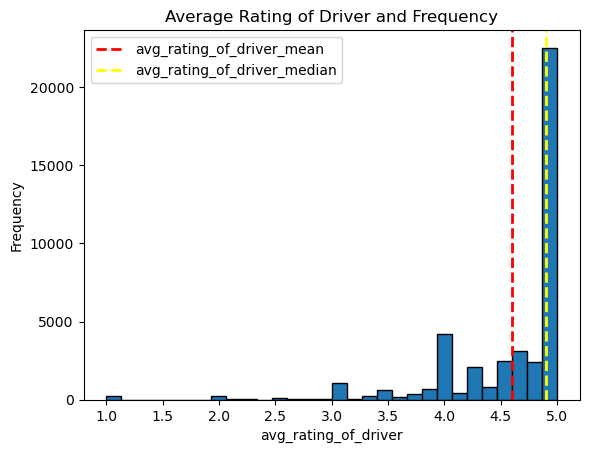

In [7]:
# Calculate mean and mode
avg_rating_of_driver_mean = df['avg_rating_of_driver'].mean()
avg_rating_of_driver_median = df['avg_rating_of_driver'].median()

# Create the histogram
fig, ax = plt.subplots()
ax.hist(df['avg_rating_of_driver'], bins=30, edgecolor='black')

# Add vertical lines for mean and mode
ax.axvline(avg_rating_of_driver_mean, color='red', linestyle='dashed', linewidth=2, label='avg_rating_of_driver_mean')
ax.axvline(avg_rating_of_driver_median, color='yellow', linestyle='dashed', linewidth=2, label='avg_rating_of_driver_median')

# Add labels and title
plt.xlabel('avg_rating_of_driver')
plt.ylabel('Frequency')
plt.title('Average Rating of Driver and Frequency')
plt.legend()

# Display the plot
plt.show()


The 'avg_rating_of_driver' histogram is left skewed. Therefore, I will fill missing values with the median.

In [8]:
# fork data
df_2 = df.copy()

# fill 'avg_rating_of_driver' missing data with median
df_2['avg_rating_of_driver'] = df_2['avg_rating_of_driver'].fillna(avg_rating_of_driver_median)

##### avg_rating_by_driver

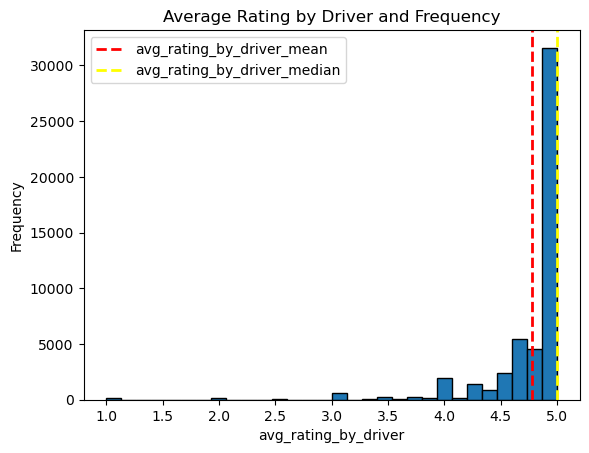

In [9]:
# Calculate mean and mode
avg_rating_by_driver_mean = df['avg_rating_by_driver'].mean()
avg_rating_by_driver_median = df['avg_rating_by_driver'].median()

# Create the histogram
fig, ax = plt.subplots()
ax.hist(df['avg_rating_by_driver'], bins=30, edgecolor='black')

# Add vertical lines for mean and mode
ax.axvline(avg_rating_by_driver_mean, color='red', linestyle='dashed', linewidth=2, label='avg_rating_by_driver_mean')
ax.axvline(avg_rating_by_driver_median, color='yellow', linestyle='dashed', linewidth=2, label='avg_rating_by_driver_median')

# Add labels and title
plt.xlabel('avg_rating_by_driver')
plt.ylabel('Frequency')
plt.title('Average Rating by Driver and Frequency')
plt.legend()

# Display the plot
plt.show()


Histogram for 'avg_rating_by_driver' is left skewed. Null values will be filled with median.

In [10]:
# fill 'avg_rating_by_driver' missing data with median
df_2['avg_rating_by_driver'] = df_2['avg_rating_by_driver'].fillna(avg_rating_by_driver_median)

##### phone

Due to small % of missing values in phone variable, the nulls will be replaced with 'unknown'

In [11]:
df_2['phone'] = df_2['phone'].fillna('Unknown')

In [12]:
df_2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   city                    50000 non-null  object        
 1   trips_in_first_30_days  50000 non-null  int64         
 2   signup_date             50000 non-null  datetime64[ns]
 3   avg_rating_of_driver    50000 non-null  float64       
 4   avg_surge               50000 non-null  float64       
 5   last_trip_date          50000 non-null  datetime64[ns]
 6   phone                   50000 non-null  object        
 7   surge_pct               50000 non-null  float64       
 8   ultimate_black_user     50000 non-null  bool          
 9   weekday_pct             50000 non-null  float64       
 10  avg_dist                50000 non-null  float64       
 11  avg_rating_by_driver    50000 non-null  float64       
dtypes: bool(1), datetime64[ns](2), float64(6), int

#### Creating 'User Activity' variable

Users are considered 'active' if they took a trip in preceding 30 days. The last date in the dataset will be used for this calculation.

In [13]:
# find last date in dataset using 'last_trip_date'

latest_date = df_2['last_trip_date'].max()
print(latest_date)

2014-07-01 00:00:00


The latest date in the dataset is July 1, 2014. 

In [14]:
# subtract 30 days from latest date to find start_window
start_window = latest_date - timedelta(days=30)
print(start_window)

2014-06-01 00:00:00


In [15]:
df_2['last_trip_month'] = pd.DatetimeIndex(df_2['last_trip_date']).month

In [16]:
df_2['user_activity'] = df_2['last_trip_month'].apply(lambda x: "Active" if x == 7 or x == 6 else "Inactive")

In [17]:
df_2.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,last_trip_month,user_activity
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,6,Active
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,5,Inactive
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,1,Inactive
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,6,Active
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,3,Inactive


## Exploratory Data Analysis

In [18]:
# fork
df_3 = df_2.copy()
colors=['red','green']


#### Visualizing The User Activity Variable

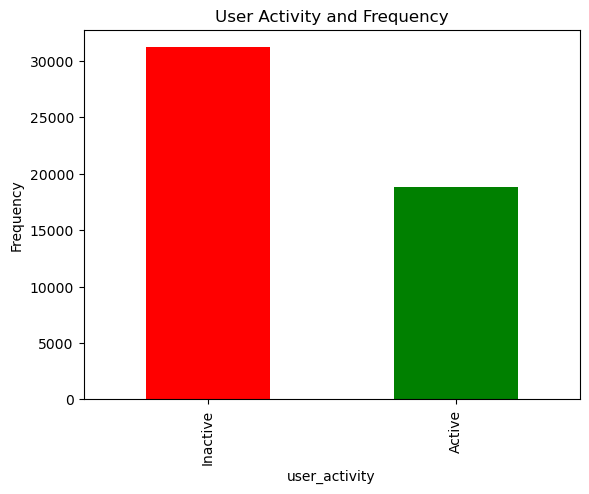

In [19]:
active_value_counts = df_3['user_activity'].value_counts()
active_value_counts.plot(kind='bar', color=colors)
plt.title('User Activity and Frequency')
plt.ylabel('Frequency')
plt.show()

The majority of users are inactive. 

#### Visualizing Categorical Variables

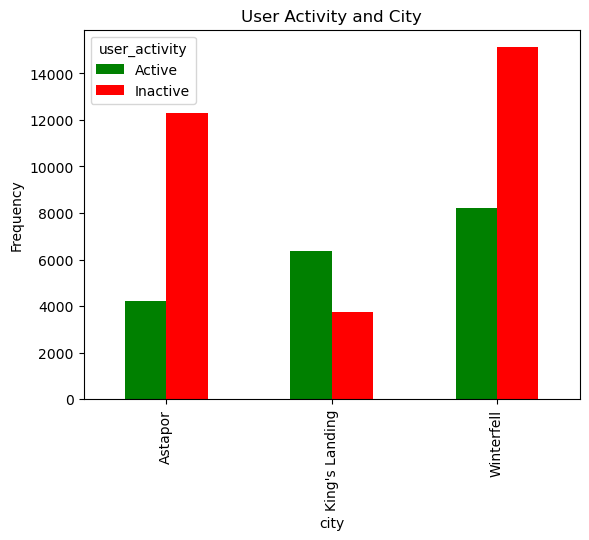

In [20]:
grouped = df_3.groupby(['city', 'user_activity']).size().unstack()
grouped.plot(kind='bar', color=['green', 'red'])
plt.title('User Activity and City')
plt.ylabel('Frequency')
plt.show()


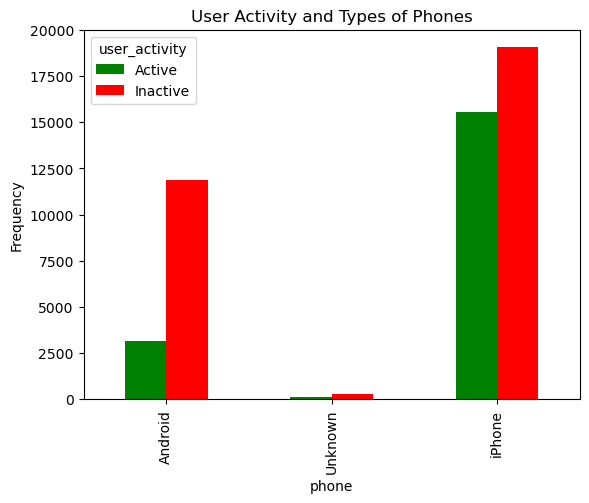

In [21]:
grouped_phone_active = df_3.groupby(['phone', 'user_activity']).size().unstack()
grouped_phone_active.plot(kind='bar', color=['green', 'red'])
plt.title('User Activity and Types of Phones')
plt.ylabel('Frequency')
plt.show()


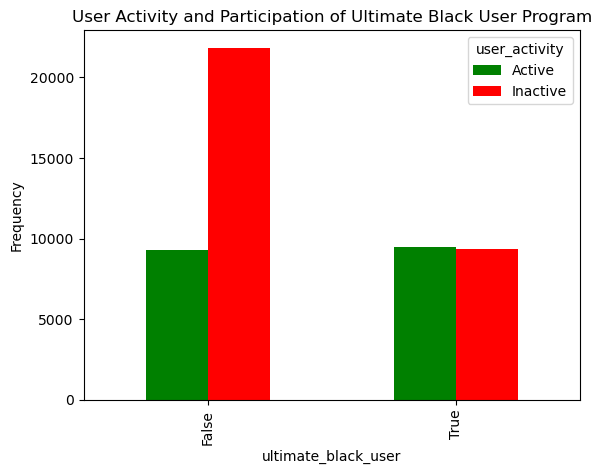

In [22]:
grouped_ultimate_black_user_active = df_3.groupby(['ultimate_black_user', 'user_activity']).size().unstack()
grouped_ultimate_black_user_active.plot(kind='bar', color=['green', 'red'])
plt.title('User Activity and Participation of Ultimate Black User Program')
plt.ylabel('Frequency')
plt.show()

#### Visualizing Quantitative Variables

In [23]:
quantitative_variables = ['trips_in_first_30_days', 'signup_date', 'avg_surge', 'last_trip_date', 'surge_pct', 'weekday_pct', 'avg_dist']
quantitative_variables_titles = ['Trips in First 30 Days', 'Signup Date', 'Average Surge', 'Last Trip Date', 'Surge Percentage', 'Weekday Percentage', 'Average Distance']

quantitative_variables_dictionary = dict(zip(quantitative_variables, quantitative_variables_titles))

<Figure size 3000x500 with 0 Axes>

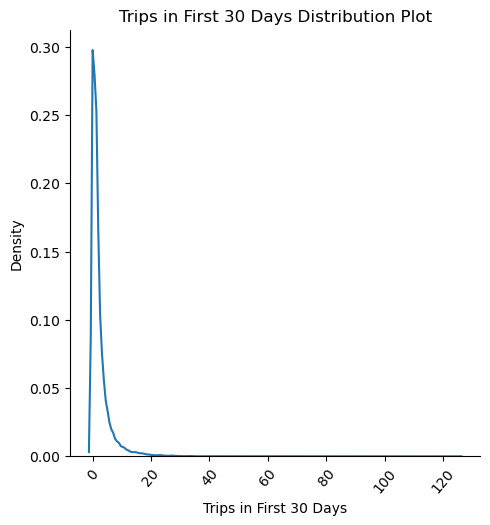

<Figure size 3000x500 with 0 Axes>

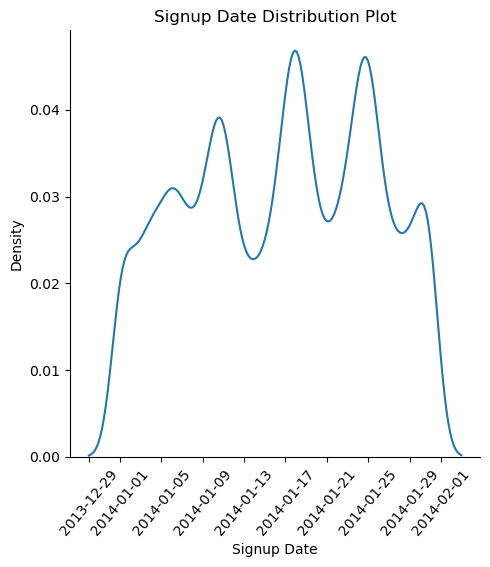

<Figure size 3000x500 with 0 Axes>

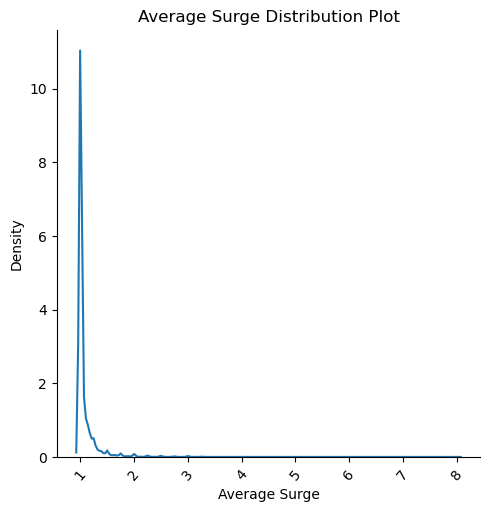

<Figure size 3000x500 with 0 Axes>

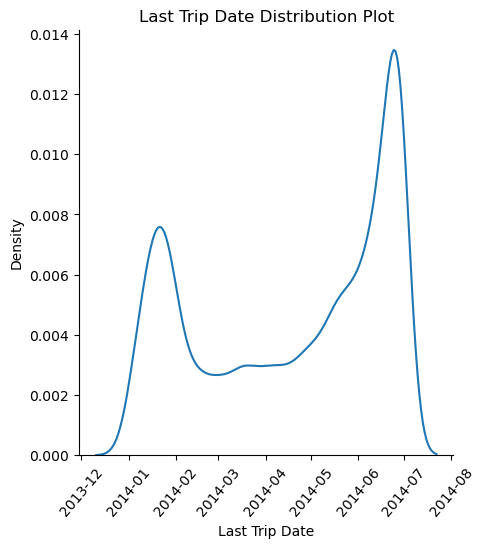

<Figure size 3000x500 with 0 Axes>

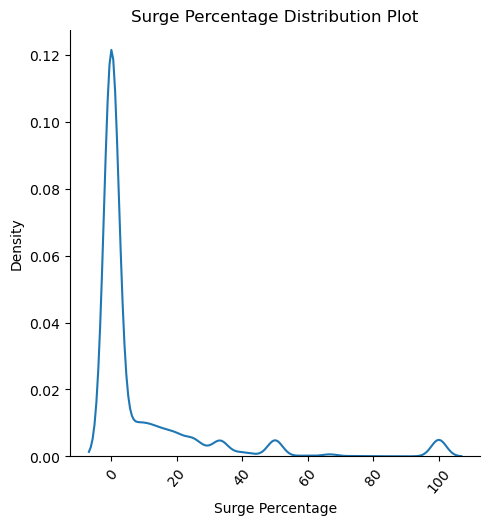

<Figure size 3000x500 with 0 Axes>

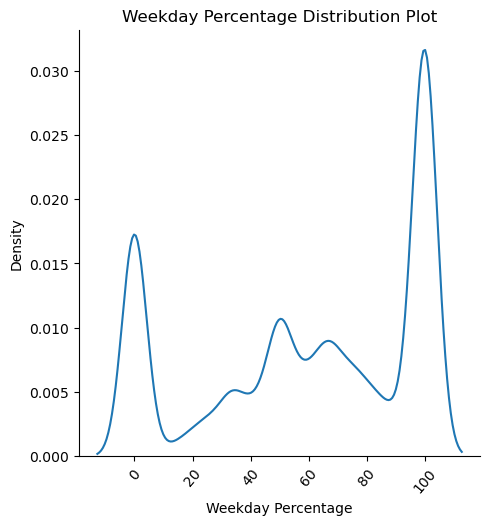

<Figure size 3000x500 with 0 Axes>

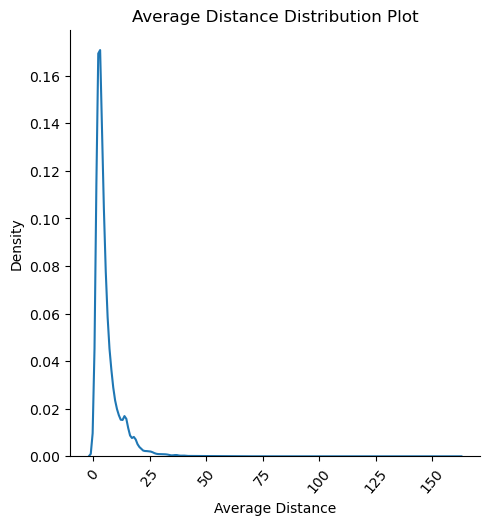

In [24]:
for variable, title in quantitative_variables_dictionary.items():
    _ = plt.figure(figsize=(30,5))
    _ = sns.displot(data=df_3, x=variable, kind='kde')
    _ = plt.title(title + ' Distribution Plot')
    _ = plt.xlabel(title)
    _ = plt.xticks(rotation=50)
    plt.show()

Initial EDA Observations
* The distributions of "trips_in_first_30_days", "avg_surge", "surge_pct", and "avg_dist" are right skewed.
* Sign up dates are peaking on weekends.
* Most users take trips during weekdays.
* The distribution of "last_trip_date" is bimodal.

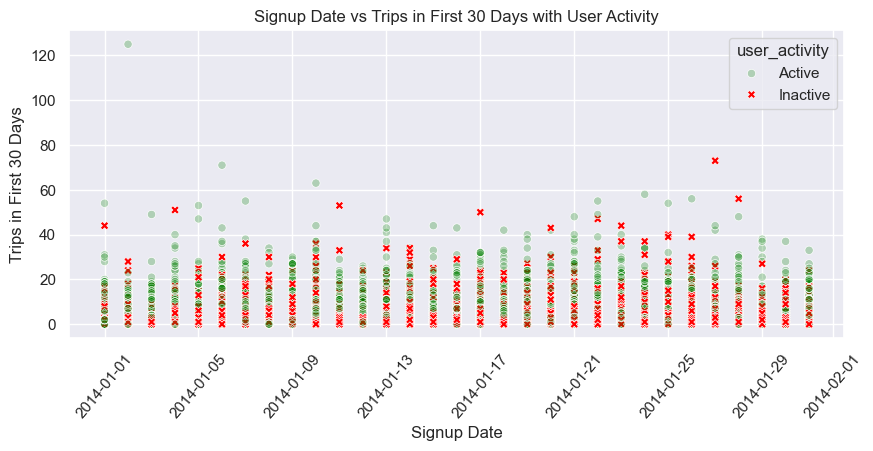

In [25]:
# value count of how many people have surge of 50 / total
from matplotlib.colors import to_rgba
color_dict = {"Active": to_rgba("green", alpha=0.25), "Inactive": to_rgba("red", alpha=1)}
_ = sns.set()
_ = plt.figure(figsize=(10,4))
_ = sns.scatterplot(x='signup_date', y='trips_in_first_30_days', data=df_3, hue='user_activity', style='user_activity', palette=color_dict)
_ = plt.xticks(rotation=50)
_ = plt.xlabel("Signup Date")
_ = plt.ylabel("Trips in First 30 Days")
_ = plt.title("Signup Date vs Trips in First 30 Days with User Activity")
_ = plt.show()

Active users took more trips in their first thirty days than inactive users.

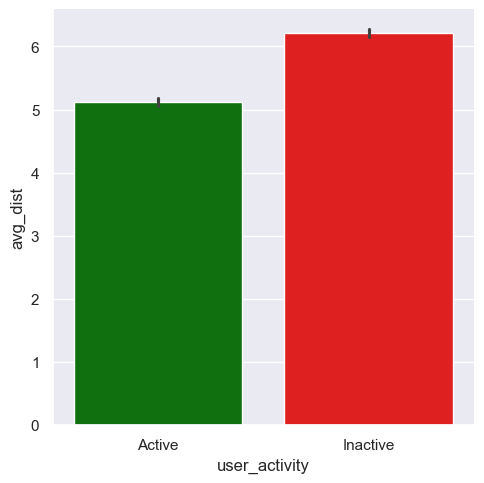

In [26]:
sns.catplot(x='user_activity', y='avg_dist', data=df_3, kind='bar', hue='user_activity',  palette=['green', 'red'])
plt.show()
#title missing

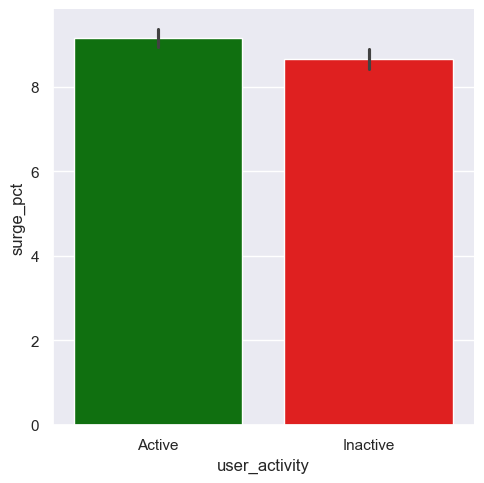

In [27]:
sns.catplot(x='user_activity', y='surge_pct', data=df_3, kind='bar', hue='user_activity',  palette=['green', 'red'])
plt.show()

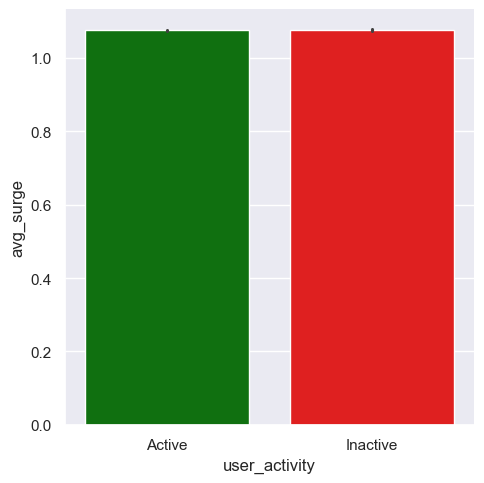

In [28]:
sns.catplot(x='user_activity', y='avg_surge', data=df_3, kind='bar', hue='user_activity',  palette=['green', 'red'])
plt.show()

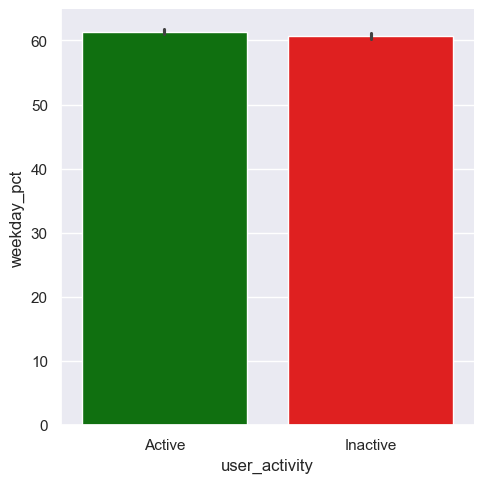

In [29]:
sns.catplot(x='user_activity', y='weekday_pct', data=df_3, kind='bar', hue='user_activity',  palette=['green', 'red'])
plt.show()

## Data Pre-Processing

#### Dummy Variables

In [30]:
df_4 = df_3.copy()
categorical_vars = ['city', 'phone', 'ultimate_black_user', 'user_activity']
df_dummy = pd.get_dummies(df_4[categorical_vars],dtype=float)
df_dummy.head()


,ultimate_black_user,city_Astapor,city_King's Landing,city_Winterfell,phone_Android,phone_Unknown,phone_iPhone,user_activity_Active,user_activity_Inactive
0,True,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
1,False,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,False,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0
3,True,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.0
4,False,0.0,0.0,1.0,1.0,0.0,0.0,0.0,1.0


#### Normalization using Min-Max Scaling

In [31]:
# this is supervised learning
# look at correlation matrix to give idea of what algorithm to use

In [32]:
df_4.head()

,city,trips_in_first_30_days,signup_date,avg_rating_of_driver,avg_surge,last_trip_date,phone,surge_pct,ultimate_black_user,weekday_pct,avg_dist,avg_rating_by_driver,last_trip_month,user_activity
0,King's Landing,4,2014-01-25,4.7,1.10,2014-06-17,iPhone,15.4,True,46.2,3.67,5.0,6,Active
1,Astapor,0,2014-01-29,5.0,1.00,2014-05-05,Android,0.0,False,50.0,8.26,5.0,5,Inactive
2,Astapor,3,2014-01-06,4.3,1.00,2014-01-07,iPhone,0.0,False,100.0,0.77,5.0,1,Inactive
3,King's Landing,9,2014-01-10,4.6,1.14,2014-06-29,iPhone,20.0,True,80.0,2.36,4.9,6,Active
4,Winterfell,14,2014-01-27,4.4,1.19,2014-03-15,Android,11.8,False,82.4,3.13,4.9,3,Inactive


In [33]:
numerical_vars = ['trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge', 'surge_pct', 'weekday_pct', 'avg_dist', 'avg_rating_by_driver']
df_numerical_vars = df_4[numerical_vars]


In [34]:
from sklearn.preprocessing import MinMaxScaler
min_max_scaler = MinMaxScaler()

In [35]:
x = df_numerical_vars.values
x_scaled = min_max_scaler.fit_transform(x)
df_scaled = pd.DataFrame(x_scaled, columns = numerical_vars)

In [36]:
dates_vars = [ 'signup_date', 'last_trip_date']
df_dates_activity_vars = df_4[dates_vars]

In [37]:
df_dates_activity_vars = pd.concat([df_dates_activity_vars, df_dummy, df_scaled], axis=1)

In [38]:
df_analysis = df_dates_activity_vars.copy()
df_analysis = df_analysis.drop('user_activity_Inactive', axis=1)


In [39]:
df_analysis.head()

,signup_date,last_trip_date,ultimate_black_user,city_Astapor,city_King's Landing,city_Winterfell,phone_Android,phone_Unknown,phone_iPhone,user_activity_Active,trips_in_first_30_days,avg_rating_of_driver,avg_surge,surge_pct,weekday_pct,avg_dist,avg_rating_by_driver
0,2014-01-25,2014-06-17,True,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.032,0.925,0.014286,0.154,0.462,0.022801,1.000
1,2014-01-29,2014-05-05,False,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.000,1.000,0.000000,0.000,0.500,0.051317,1.000
2,2014-01-06,2014-01-07,False,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.024,0.825,0.000000,0.000,1.000,0.004784,1.000
3,2014-01-10,2014-06-29,True,0.0,1.0,0.0,0.0,0.0,1.0,1.0,0.072,0.900,0.020000,0.200,0.800,0.014662,0.975
4,2014-01-27,2014-03-15,False,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.112,0.850,0.027143,0.118,0.824,0.019446,0.975


<Axes: >

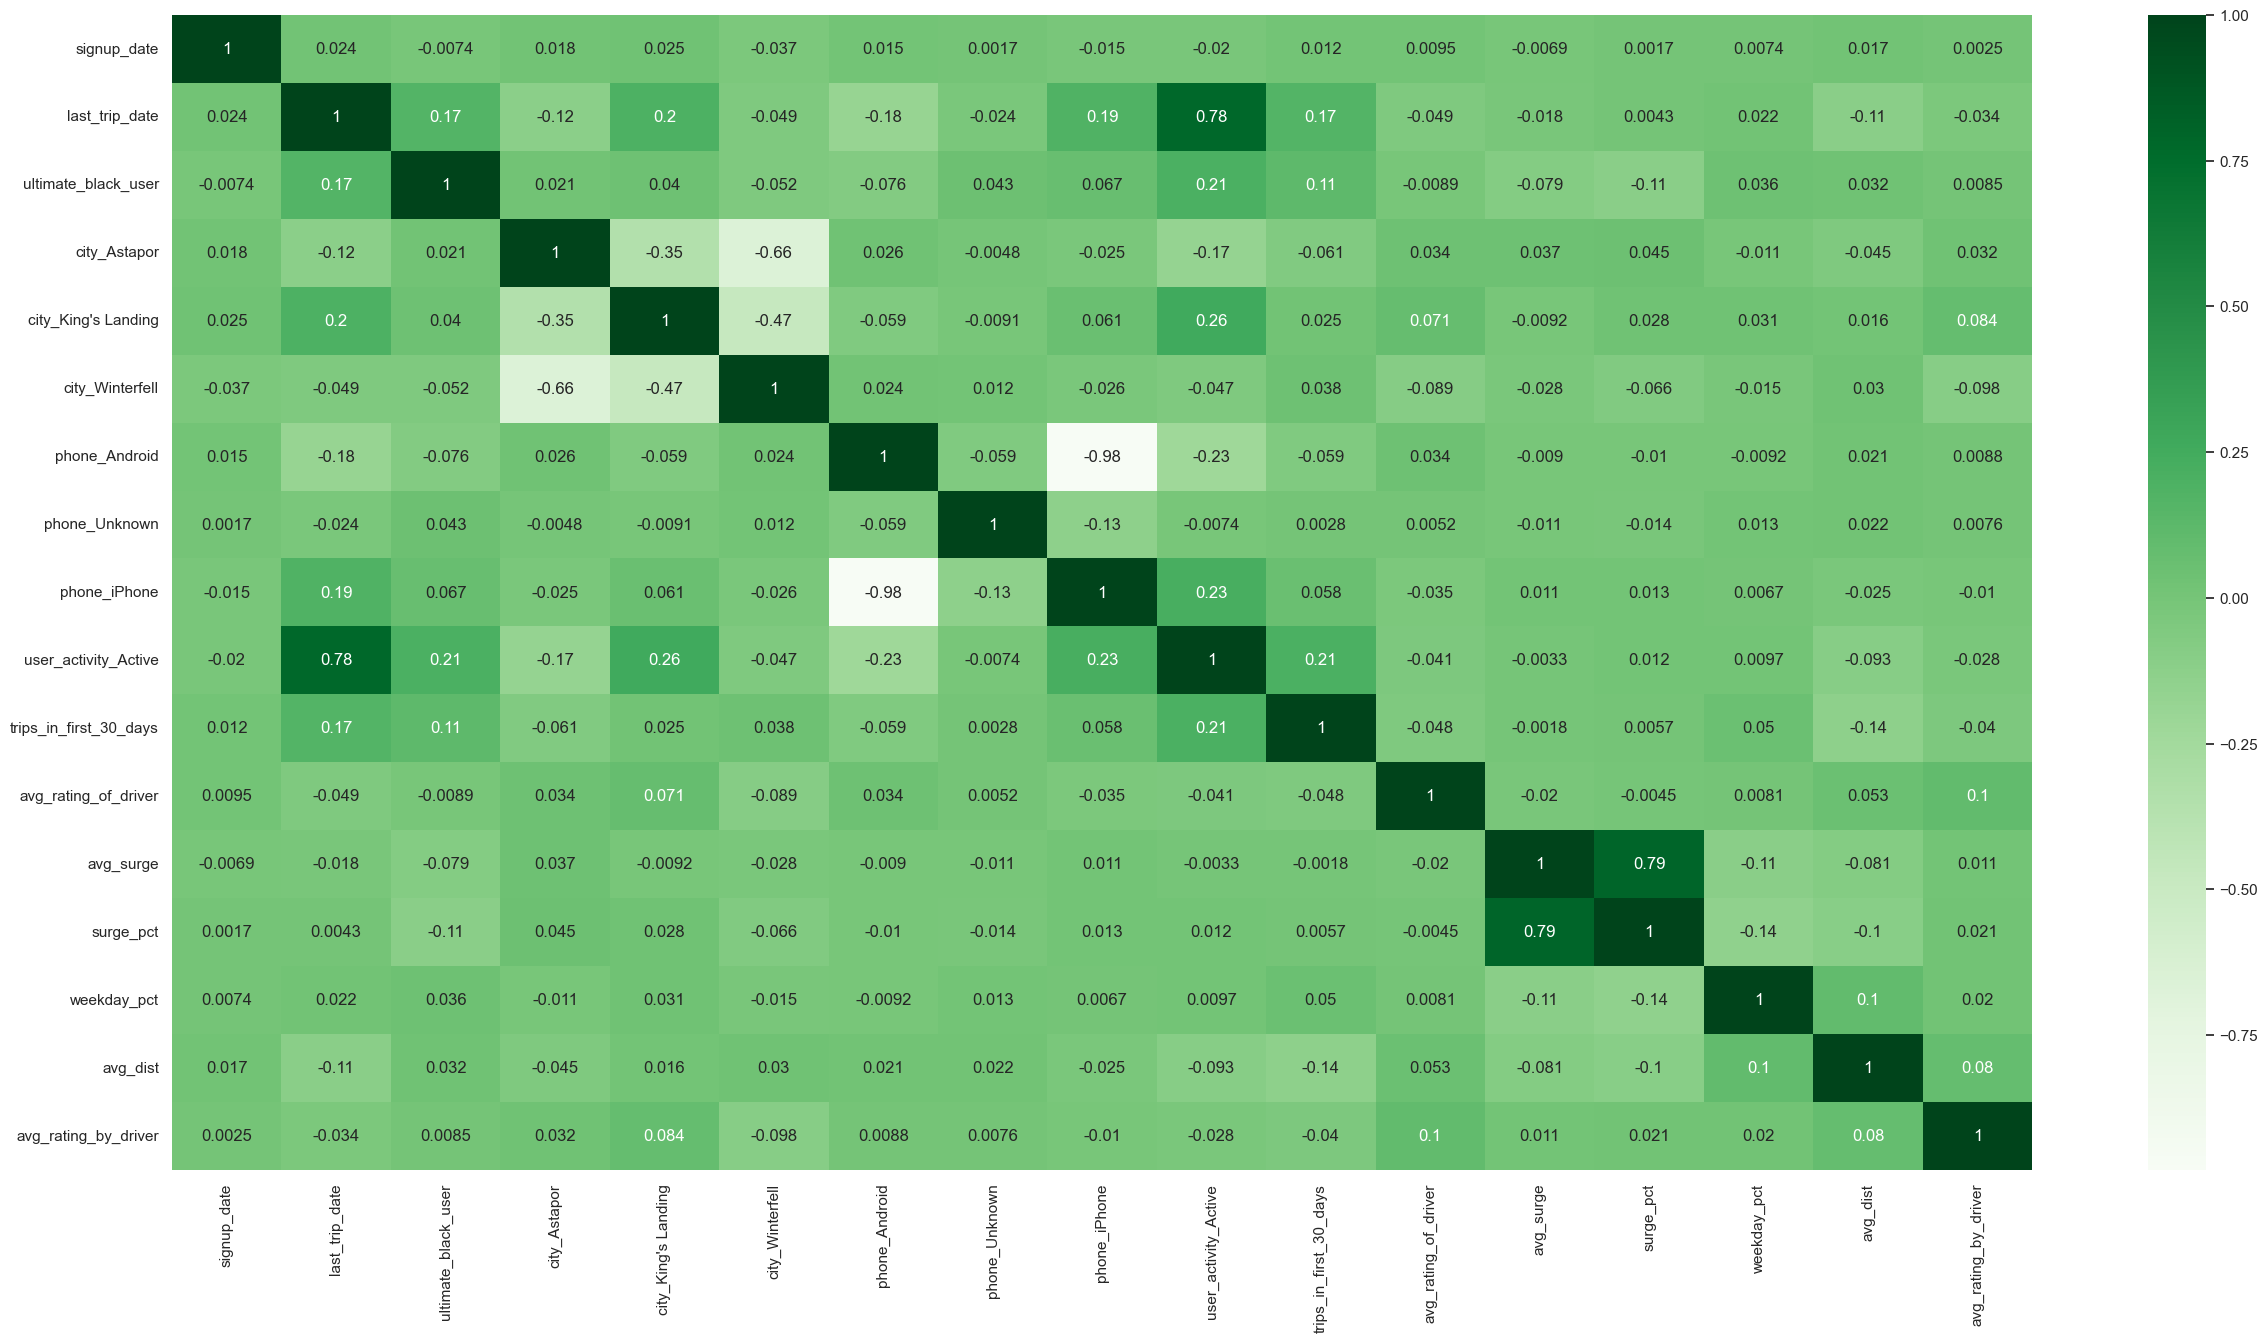

In [40]:
plt.figure(figsize=(30,15))
matrix = df_analysis.corr()

# plotting correlation matrix
sns.heatmap(matrix, cmap="Greens", annot=True)

Observations
The following variables have negligible correlation with user activity:
* avg_surge: r = -0.0033
* phone_unknown: r = -0.0074
* 

- Decision Tree
- Random Forest
- XGBoost

In [41]:
features = []
for i in df_analysis.columns:
    if i != 'user_activity_Active' and i != 'last_trip_date' and i != 'signup_date':
        features.append(i)
print(features)

['ultimate_black_user', 'city_Astapor', "city_King's Landing", 'city_Winterfell', 'phone_Android', 'phone_Unknown', 'phone_iPhone', 'trips_in_first_30_days', 'avg_rating_of_driver', 'avg_surge', 'surge_pct', 'weekday_pct', 'avg_dist', 'avg_rating_by_driver']


In [42]:
# Decision Tree
from sklearn import tree
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn import metrics 

X = df_analysis[features]
y = df_analysis['user_activity_Active']

# Split dataset into training set and test set
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=1) # 70% training and 30% test 

# train model
dtree = DecisionTreeClassifier(criterion="entropy", max_depth=4)
dtree = dtree.fit(X_train,y_train)

#Predict the response for test dataset
y_pred = dtree.predict(X_test)

print("ACCURACY OF THE DECISION TREE MODEL:", metrics.accuracy_score(y_test, y_pred))
print("PRECISION OF THE DECISION TREE MODEL:", metrics.precision_score(y_test, y_pred))
print("RECALL OF THE DECISION TREE MODEL:", metrics.recall_score(y_test, y_pred))
print("F1-SCORE OF THE DECISION TREE MODEL:", metrics.f1_score(y_test, y_pred))

ACCURACY OF THE DECISION TREE MODEL: 0.744
PRECISION OF THE DECISION TREE MODEL: 0.6631744368779465
RECALL OF THE DECISION TREE MODEL: 0.6652653704676826
F1-SCORE OF THE DECISION TREE MODEL: 0.664218258132214


In [43]:
!pip install pydotplus

In [44]:
conda install graphviz

Retrieving notices: ...working... done
Solving environment: done


==> WARNING: A newer version of conda exists. <==
  current version: 24.9.2
  latest version: 25.5.1

Please update conda by running

    $ conda update -n base -c defaults conda

Or to minimize the number of packages updated during conda update use

     conda install conda=25.5.1



## Package Plan ##

  environment location: /Users/itssel/Anaconda3/anaconda3

  added / updated specs:
    - graphviz


The following packages will be downloaded:

    package                    |            build
    ---------------------------|-----------------
    certifi-2025.6.15          |  py312hca03da5_0         157 KB
    ------------------------------------------------------------
                                           Total:         157 KB

The following packages will be UPDATED:

  certifi                         2025.4.26-py312hca03da5_0 --> 2025.6.15-py312hca03da5_0 



                                                   

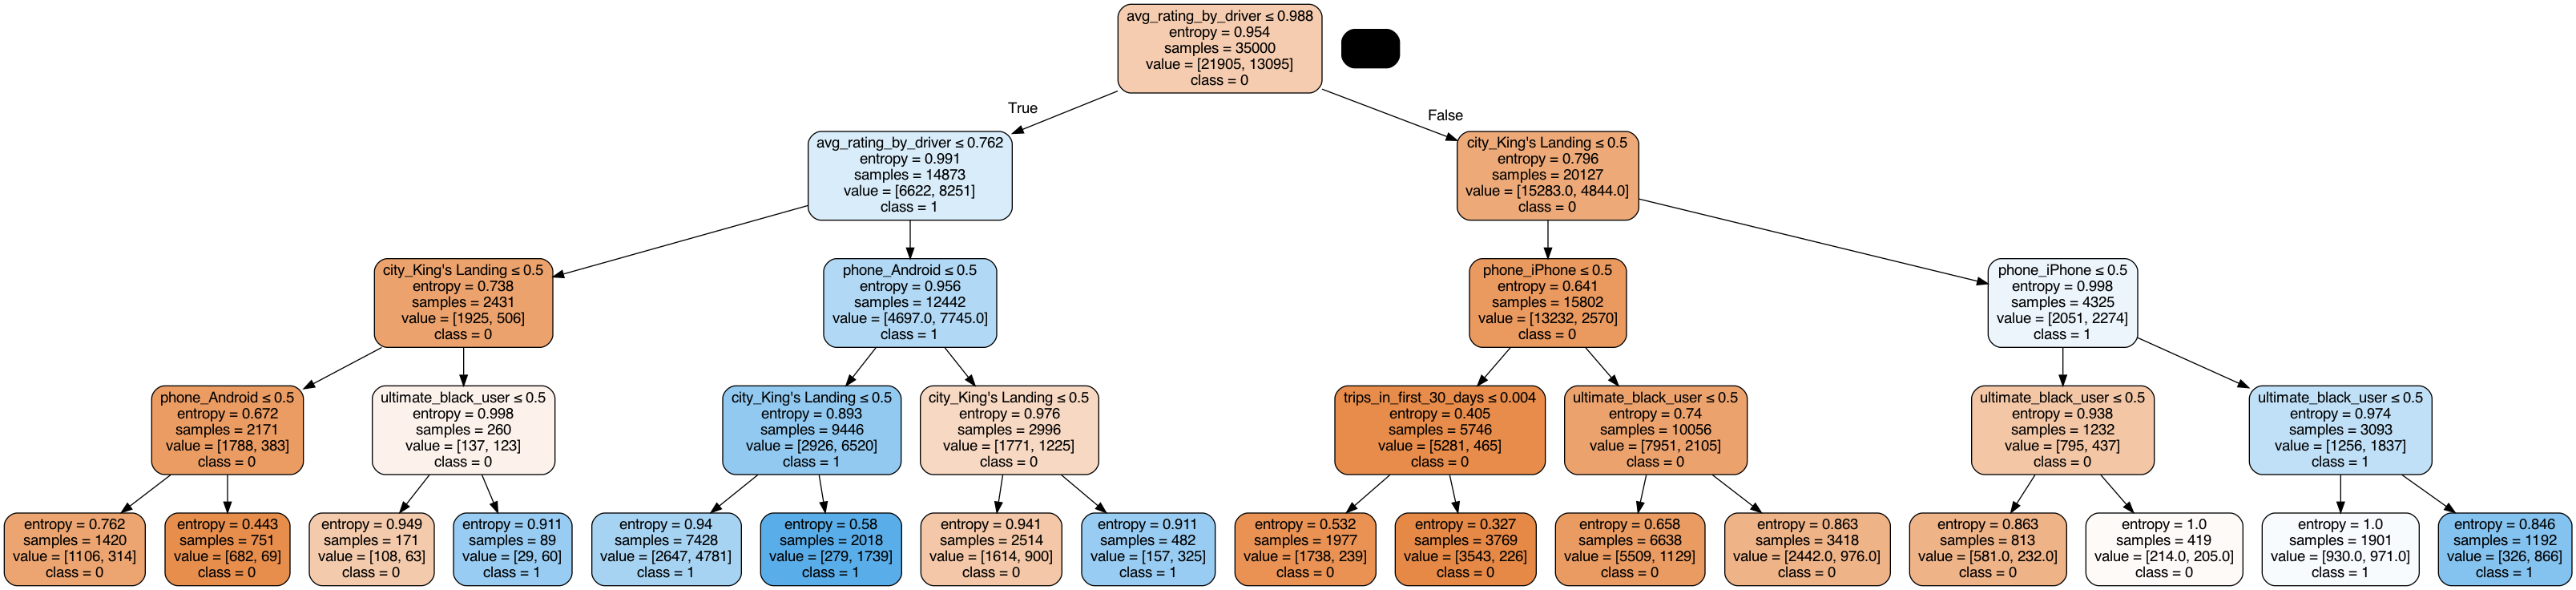

In [45]:
from six import StringIO 
from IPython.display import Image  
from sklearn.tree import export_graphviz
import pydotplus
dot_data = StringIO()
export_graphviz(dtree, out_file=dot_data,  
                filled=True, rounded=True,
                special_characters=True, feature_names = features,class_names=['0','1'])
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())  
graph.write_png('active.png')
Image(graph.create_png())

In [46]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators = 100, max_depth=7, criterion='entropy')

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print("ACCURACY OF THE RANDOM FOREST MODEL:", metrics.accuracy_score(y_test, y_pred))
print("PRECISION OF THE RANDOM FOREST MODEL:", metrics.precision_score(y_test, y_pred))
print("RECALL OF THE RANDOM FOREST MODEL:", metrics.recall_score(y_test, y_pred))
print("F1-SCORE OF THE RANDOM FOREST MODEL:", metrics.f1_score(y_test, y_pred))

ACCURACY OF THE RANDOM FOREST MODEL: 0.7804
PRECISION OF THE RANDOM FOREST MODEL: 0.7513007284079084
RECALL OF THE RANDOM FOREST MODEL: 0.6323349097915572
F1-SCORE OF THE RANDOM FOREST MODEL: 0.6867034430283432


## Default parameters for XGBoost

- 'max_depth': default=6
- 'learning_rate': default=0.3
- 'subsample': default=1
- 'n_estimators': 

In [47]:
%%time

from xgboost import XGBClassifier

from sklearn.model_selection import train_test_split

X = df_analysis[features]
y = df_analysis['user_activity_Active']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.3)

# create model instance
xgb = XGBClassifier(n_estimators=100, max_depth=3, learning_rate=1, objective='binary:logistic')
# fit model
xgb.fit(X_train, y_train)
# make predictions
y_pred_xgb = xgb.predict(X_test)
print("ACCURACY OF THE XGBOOST MODEL:", metrics.accuracy_score(y_test, y_pred_xgb))
print("PRECISION OF THE XGBOOST MODEL:", metrics.precision_score(y_test, y_pred_xgb))
print("RECALL OF THE XGBOOST MODEL:", metrics.recall_score(y_test, y_pred_xgb))
print("F1-SCORE OF THE XGBOOST MODEL:", metrics.f1_score(y_test, y_pred_xgb))

ACCURACY OF THE XGBOOST MODEL: 0.7896
PRECISION OF THE XGBOOST MODEL: 0.7510064412238325
RECALL OF THE XGBOOST MODEL: 0.6603539823008849
F1-SCORE OF THE XGBOOST MODEL: 0.702768883028819
CPU times: user 422 ms, sys: 271 ms, total: 693 ms
Wall time: 210 ms


In [48]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred_xgb))

              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84      9350
         1.0       0.75      0.66      0.70      5650

    accuracy                           0.79     15000
   macro avg       0.78      0.76      0.77     15000
weighted avg       0.79      0.79      0.79     15000



In [49]:
# f1 confusion matrix, precision, and recall for each model
# try logistic regression after ROC. ROC is prioritiy.
# ROC curve for all models & see which one has biggest area under the curve. This should correspond to scores of models. 
# ROC graph can help figure out the threshold. Tweaking threshold could increase scores.
# score 80s-90s is indicator of good model. F1-score is harmonic balance of recall and precision. 

In [50]:
%%time
# xgboost grid search
from sklearn.model_selection import GridSearchCV
# Define the hyperparameter grid
param_grid = {
    'max_depth': [3, 5, 7],
    # 'learning_rate': [0.1, 0.01, 0.001],
    'learning_rate': [0.5, 2],
    'subsample': [0.5, 0.7, 1],
    'n_estimators': [200, 1000]
}
xgb = XGBClassifier()

# Create the GridSearchCV object
grid_search = GridSearchCV(xgb, param_grid=param_grid, cv=5, scoring='f1')

# Fit the GridSearchCV object to the training data
grid_search.fit(X_train, y_train)

# Print the best set of hyperparameters and the corresponding score
#print("Best set of hyperparameters: ", grid_search.best_params_)
#print("Best score: ", grid_search.best_score_)

CPU times: user 6min 45s, sys: 3min 16s, total: 10min 1s
Wall time: 1min 7s


GridSearchCV(cv=5,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False, eval_metric=None,
                                     feature_types=None, feature_weights=None,
                                     gamma=None, grow_policy=None,
                                     importance_type=None,
                                     interaction_constraints=Non...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             param_grid={'learning_rate': [0.5, 2], 'max_depth': [3, 5, 7],
                         'n_estimators': [200, 1000],
                         'subsample': [0.5, 0.7, 1]},
             scoring='f1')

In [51]:
# we learned that learning rate of 1 gave us highest accuracy. Chances are that a higher learning rate is better.
# test 1: Best set of hyperparameters:  {'learning_rate': 0.1, 'max_depth': 5, 'subsample': 0.7}
# test 1: Best score:  0.7869999999999999
# random search is a different technique. instead of checking all combinations, random grid search

In [52]:
# random forest grid search
''' rfc_grid = RandomForestClassifier(random_state=6)
param_grid = {'n_estimators': [200, 400, 600], 'max_depth': [5, 15, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 3, 5]}
grid = GridSearchCV(rfc_grid, param_grid, cv=3, scoring='f1')
grid.fit(X_train, y_train)
y_pred_rfc = grid.predict(X_test)
print(grid.score(X_test, y_test)) '''

# randomized search cv
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import uniform
rfc_randomized_search_cv = RandomForestClassifier(random_state=6)
param_grid = {'n_estimators': [200, 400, 600], 'max_depth': [5, 15, 20], 'min_samples_split': [2, 5, 10], 'min_samples_leaf': [1, 3, 5]}
random_search = RandomizedSearchCV(rfc_randomized_search_cv, param_grid, cv=3, scoring='f1')
random_search.fit(X_train, y_train)
y_pred_random_search = random_search.predict(X_test)
print(random_search.score(X_test, y_test))
print("Best set of hyperparameters: ", random_search.best_params_)


0.7025800963992062
Best set of hyperparameters:  {'n_estimators': 400, 'min_samples_split': 2, 'min_samples_leaf': 5, 'max_depth': 20}


In [53]:
# use grid search best parameters for new xgb
from xgboost import XGBClassifier
xgb_grid_params = XGBClassifier(learning_rate=0.5, max_depth=3, n_estimators=200, subsample=1)
xgb_grid_params.fit(X_train, y_train)
y_pred_xgb_gp = xgb_grid_params.predict(X_test)
print(xgb_grid_params.score(X_test, y_test))
print("F1-SCORE OF THE TUNED XGBOOST MODEL:", metrics.f1_score(y_test, y_pred_xgb_gp))

0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688


In [54]:
print(classification_report(y_test, y_pred_xgb_gp))

              precision    recall  f1-score   support

         0.0       0.81      0.87      0.84      9350
         1.0       0.76      0.67      0.71      5650

    accuracy                           0.79     15000
   macro avg       0.78      0.77      0.78     15000
weighted avg       0.79      0.79      0.79     15000



In [55]:
# use grid search best parameters for new xgb
from xgboost import XGBClassifier
xgb_grid_params = XGBClassifier(learning_rate=0.5, max_depth=3, n_estimators=200, subsample=1)
xgb_grid_params.fit(X_train, y_train)
# Step 2: Apply a custom threshold
threshold = 0.409  # or your optimal value
y_pred_xgb_gp = xgb_grid_params.predict(X_test)
y_pred = (y_pred_xgb_gp >= threshold).astype(int)
print(xgb_grid_params.score(X_test, y_test))
print("F1-SCORE OF THE TUNED XGBOOST MODEL:", metrics.f1_score(y_test, y_pred))

0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688


In [56]:
xgb_feature_importance = xgb_grid_params.feature_importances_
for feature, importance in zip(features, xgb_feature_importance):
    print(feature, ':', importance)

ultimate_black_user : 0.12309207
city_Astapor : 0.07735032
city_King's Landing : 0.31618047
city_Winterfell : 0.007886611
phone_Android : 0.16756953
phone_Unknown : 0.0063841348
phone_iPhone : 0.07665292
trips_in_first_30_days : 0.016539287
avg_rating_of_driver : 0.011892453
avg_surge : 0.03112508
surge_pct : 0.025144342
weekday_pct : 0.033941634
avg_dist : 0.008344089
avg_rating_by_driver : 0.0978971


In [57]:
from xgboost import plot_importance

def feature_importance(feature_list, model):
    model_feature_importance = model.feature_importances_
    unsorted_labeled_feature_importance = zip(features, model_feature_importance)
    for feature, importance in unsorted_labeled_feature_importance:
        print(feature, ':', importance)

   # plot_importance(model) why is this not lining up with the feature importance

In [58]:
feature_importance(features, xgb_grid_params)

ultimate_black_user : 0.12309207
city_Astapor : 0.07735032
city_King's Landing : 0.31618047
city_Winterfell : 0.007886611
phone_Android : 0.16756953
phone_Unknown : 0.0063841348
phone_iPhone : 0.07665292
trips_in_first_30_days : 0.016539287
avg_rating_of_driver : 0.011892453
avg_surge : 0.03112508
surge_pct : 0.025144342
weekday_pct : 0.033941634
avg_dist : 0.008344089
avg_rating_by_driver : 0.0978971


In [59]:
feature_importance(features, rf)

ultimate_black_user : 0.06312398918899947
city_Astapor : 0.03362708899596714
city_King's Landing : 0.14010842067022858
city_Winterfell : 0.019234726665428727
phone_Android : 0.06423815635305652
phone_Unknown : 0.0007539635988179266
phone_iPhone : 0.054984714536606125
trips_in_first_30_days : 0.05564085471163171
avg_rating_of_driver : 0.02037410236752248
avg_surge : 0.10524543677176922
surge_pct : 0.12850878150020859
weekday_pct : 0.11748709529926277
avg_dist : 0.022333255365886942
avg_rating_by_driver : 0.17433941397461383


In [60]:
print("Best score: ", random_search.best_score_)

Best score:  0.6885934919038602


In [61]:
#roc curv - may help answer q regarding imbalance in f1 score

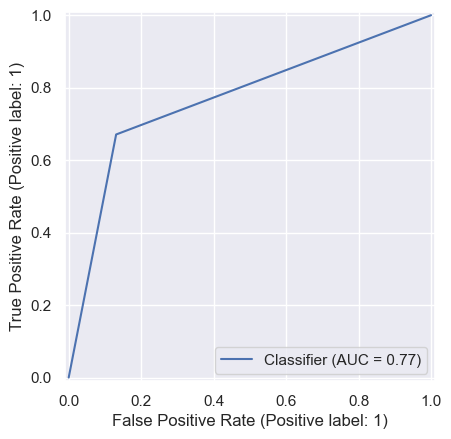

In [62]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.metrics import RocCurveDisplay
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
RocCurveDisplay.from_predictions(
   y_test, y_pred_xgb_gp)

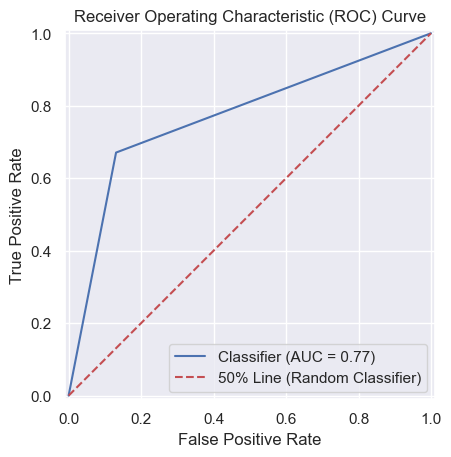

In [63]:
# Plot the ROC curve and the 50% line
# roc_display = RocCurveDisplay(fpr=fpr, tpr=tpr).plot()

roc_display = RocCurveDisplay.from_predictions(
   y_test, y_pred_xgb_gp)
plt.plot([0, 1], [0, 1], linestyle='--', color='r', 
         label='50% Line (Random Classifier)')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend()
plt.show()

In [64]:
'''# ask gem or chatgpt how to find the ordered pair
# Get predicted probabilities for the test set
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
#COMPARE ROC'''

'# ask gem or chatgpt how to find the ordered pair\n# Get predicted probabilities for the test set\ny_prob = model.predict_proba(X_test)[:, 1]\n\n# Calculate the ROC curve\nfpr, tpr, thresholds = roc_curve(y_test, y_prob)\n#COMPARE ROC'

In [65]:
'''# Get predicted probabilities for the test set
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate the ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)'''

'# Get predicted probabilities for the test set\ny_prob = model.predict_proba(X_test)[:, 1]\n\n# Calculate the ROC curve\nfpr, tpr, thresholds = roc_curve(y_test, y_prob)'

threshold array: [       inf 0.8630137  0.77805109 0.68308351 0.65       0.60406504
 0.57490548 0.50074738 0.36523126 0.33333333 0.29456384 0.27405476
 0.22102232 0.16727446 0.1140646  0.09681698 0.05129194]
optimal_threshold  0.5007473841554559
threshold array: [       inf 0.99001616 0.98300931 ... 0.00808911 0.00706882 0.00682499]
optimal_threshold  0.40500443664392843
threshold array: [          inf 9.9787974e-01 9.9075466e-01 ... 2.8353876e-03 2.8109562e-03
 1.7374381e-04]
optimal_threshold  0.3813643


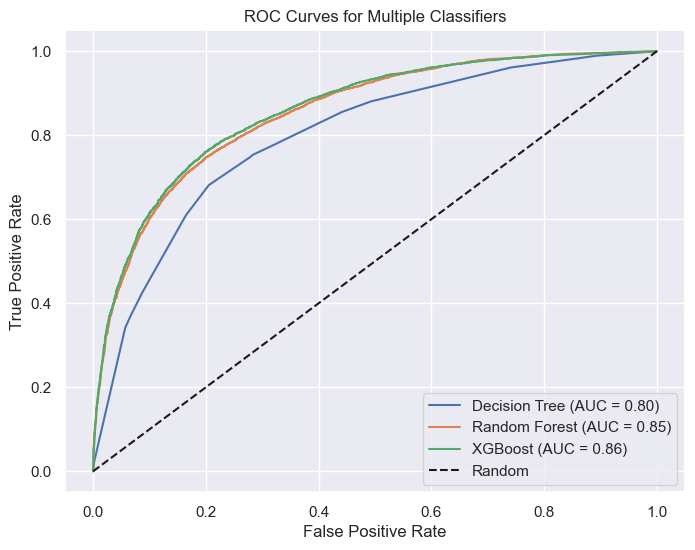

In [66]:
from sklearn import metrics
import numpy as np

models = {
    "Decision Tree": DecisionTreeClassifier(criterion="entropy", max_depth=4),
    "Random Forest": RandomForestClassifier(random_state=6,n_estimators=600, min_samples_split=5, min_samples_leaf=5, max_depth=15),
    "XGBoost": XGBClassifier(learning_rate=0.5, max_depth=3, n_estimators=200, subsample=1)
}

# Fit models
for model in models.values():
    model.fit(X_train, y_train)
plt.figure(figsize=(8, 6))

for name, model in models.items():
    y_score = model.predict_proba(X_test)[:, 1]
    fpr, tpr, thresholds = metrics.roc_curve(y_test, y_score)
    roc_auc = metrics.auc(fpr, tpr)
    # 1. Youden’s J statistic
    J = tpr - fpr
    idx = np.argmax(J)
    optimal_threshold = thresholds[idx]
    print("threshold array:", thresholds)
    print("optimal_threshold ", optimal_threshold)

    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.2f})")
    
# Add baseline and labels
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Multiple Classifiers")
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

In [67]:
# next steps: 
# modeling with XGBoost
# talk about F1 score or the best harmonization between precision and recall occurs at ___
# anywhere between (0.2 ,0.75) and (0.25, 0.80) will maximize the difference between the false positive rate and true positive rate
# the threshold that we'd want to use for binary classification
# # 1. Youden’s J statistic
# J = tpr - fpr
# idx = np.argmax(J)
# optimal_threshold = thresholds[idx]


## Optimal F1_Score for XGBoost


In [77]:
# use grid search best parameters for new xgb
from xgboost import XGBClassifier
xgb_grid_params = XGBClassifier(learning_rate=0.5, max_depth=3, n_estimators=200, subsample=1)
xgb_grid_params.fit(X_train, y_train)
# Step 2: Apply a custom threshold
threshold = 0.78  # or your optimal value
y_pred_xgb_gp = xgb_grid_params.predict(X_test)
y_pred_xgb_proba = xgb_grid_params.predict_proba(X_test)

# get the second element of each array in y_pred_xgb_proba
second_y_pred_xgb_proba = [x[1] for x in y_pred_xgb_proba]
y_pred = (y_pred_xgb_proba >= threshold).astype(int)

#y_pred = (second_y_pred_xgb_proba >= threshold).astype(int)

print(xgb_grid_params.score(X_test, y_test))
# print("F1-SCORE OF THE TUNED XGBOOST MODEL:", metrics.f1_score(y_test, y_pred))
print(y_pred) # should just be a list of 1's and 0's.  print type of each. this is probably why line 12 is breaking
print(y_test)
#print(type(y_pred_xgb_proba))
#print(y_pred_xgb_proba.shape)
#print(y_pred_xgb_proba)
#print(type(y_pred_xgb_proba[0]))
#print(y_pred_xgb_proba[0])
#print(second_y_pred_xgb_proba)

print(y_pred_xgb_gp.shape)
print(type(y_pred_xgb_gp))
print(y_pred_xgb_gp)


0.7944
[[1 0]
 [1 0]
 [0 0]
 ...
 [0 1]
 [0 1]
 [1 0]]
37819    0.0
16456    0.0
40041    1.0
49432    1.0
2796     0.0
        ... 
14366    0.0
25325    0.0
28502    1.0
29015    0.0
46783    0.0
Name: user_activity_Active, Length: 15000, dtype: float64
(15000,)
<class 'numpy.ndarray'>
[0 0 1 ... 1 1 0]


In [69]:
threshold_list = [0 ,0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
for threshold in threshold_list:
    y_pred = (y_pred_xgb_gp >= threshold).astype(int)
    print(threshold)
    print(xgb_grid_params.score(X_test, y_test))
    print("F1-SCORE OF THE TUNED XGBOOST MODEL:", metrics.f1_score(y_test, y_pred))
    

0
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.5472154963680388
0.1
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.2
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.3
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.4
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.5
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.6
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.7
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.8
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
0.9
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
1.0
0.7944
F1-SCORE OF THE TUNED XGBOOST MODEL: 0.7108027006751688
